In [24]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from concurrent.futures import ThreadPoolExecutor
from langgraph.graph import StateGraph,START,END

llm = ChatGroq(
    model='openai/gpt-oss-20b',
    temperature=0.2
)

In [25]:
from pydantic import BaseModel
from typing import List,TypedDict

class llm_schema(BaseModel):
    tasks: List[str]

class State(TypedDict):
    query:str
    tasks:List[str]
    results:List[str]
    summary:str

llm_with_schema = llm.with_structured_output(llm_schema)


In [26]:
def orchestrator_node(state:State):
    prompt = ChatPromptTemplate.from_messages([
        ('system','you are orchestrator node your work is to divide user query into tasks'),
        ('user','{query} divide this into tasks')
    ])
    chain = prompt | llm_with_schema
    response = chain.invoke({'query':state['query']})
    state['tasks']= response.tasks
    return state




In [27]:
def execute_node(query:str):
    return llm.invoke(query).content


In [28]:
def worker_node(state:State):
    tasks = state['tasks']
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        result_futures= executor.map(execute_node,tasks)
        for result in result_futures:
            results.append(result)
        
    state['results']= results
    return state
    

In [29]:
def summerize_node(state:State):
    prompt = ChatPromptTemplate.from_messages([
       ('system','Your work is to summerize the given details of result'),
       ('user','{result}')
    ])

    chain = prompt | llm
    response = chain.invoke({'result':state['results']})
    state['summary'] = response.content
    return state

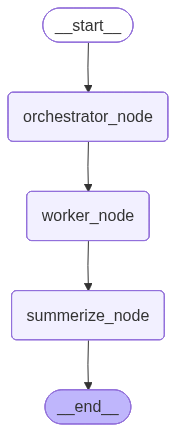

In [30]:
orchestrator_graph = StateGraph(State)

orchestrator_graph.add_node("orchestrator_node",orchestrator_node)
orchestrator_graph.add_node("worker_node",worker_node)
orchestrator_graph.add_node("summerize_node",summerize_node)

orchestrator_graph.add_edge(START,"orchestrator_node")
orchestrator_graph.add_edge("orchestrator_node","worker_node")
orchestrator_graph.add_edge("worker_node","summerize_node")
orchestrator_graph.add_edge("summerize_node",END)

ograph = orchestrator_graph.compile()
from IPython.display import Image

Image(ograph.get_graph().draw_mermaid_png())


In [31]:
output = ograph.invoke({
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    }
)

output

{'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?',
 'tasks': ['Find capital of France',
  'Find population of Paris',
  'Find capital of Germany',
  'Find population of Berlin'],
 'results': ['The capital of France is **Paris**.',
  '**Population of Paris (city proper)**  \n- **Estimated population (2023‑2024):** **≈\u202f2,140,000** residents  \n- **Source:** French National Institute of Statistics and Economic Studies (INSEE) – “Populations légales 2023” and the 2024 mid‑year estimate.\n\n**Population of the Paris metropolitan area (Grand Paris)**  \n- **Estimated population (2023):** **≈\u202f12,000,000** residents  \n- **Source:** INSEE – “Population du Grand Paris” (2023) and the 2024 update.\n\n**Key points**\n\n| Category | Population | Notes |\n|----------|------------|-------|\n| City proper (commune of Paris) | ~2.14\u202fmillion | Includes only the 20 arrondissements within th